# Optimal Stopping with Signatures

Numerical implementation of **Bayer, Hager, Riedel & Schoenmakers (2021)**,
*Optimal Stopping with Signatures*, [arXiv:2105.00778](https://arxiv.org/abs/2105.00778).

The paper solves optimal stopping problems

$$V^* \;=\; \sup_{\tau \in \mathcal{S}} \mathbb{E}\left[Y_{\tau \wedge T}\right]$$

under minimal assumptions on the underlying process $X$: it only needs to be a continuous
(geometric) random rough path. In particular $X$ may be **non-Markovian and not a
semimartingale** — e.g. fractional Brownian motion with $H \neq 1/2$ — a setting where
classical dynamic programming breaks down.

This notebook reproduces the two numerical experiments of Section 8:

1. **Optimal stopping of fractional Brownian motion** ($Y \equiv X^H$), benchmarked against
   Table 2 of the paper and the Deep Optimal Stopping values of Becker–Cheridito–Jentzen (2019);
2. **An American put in a rough electricity market** (Bennedsen 2017 model), benchmarked
   against Table 3.

Both the **deep log-signature policies** (Section 7) and the **linear signature policies**
(Section 5) are implemented.


## 1. Method in a nutshell

**Randomized stopping times (Section 4).** For a continuous stopping policy
$\theta : \Lambda_T \to \mathbb{R}$ and $Z \sim \mathrm{Exp}(1)$ independent of $X$, define

$$\tau^r_\theta := \inf\Big\{ t \ge 0 \;:\; \int_0^{t \wedge T} \theta(\hat X|_{[0,s]})^2\, \mathrm{d}s \;\ge\; Z \Big\},$$

where $\hat X_t = (t, X_t)$ is the time-augmented path. Randomization makes the expected
payoff **differentiable in $\theta$** (Proposition 4.4) without changing the optimal value
(Proposition 4.2):

$$\mathbb{E}\big[Y_{\tau^r_\theta \wedge T}\big] = \mathbb{E}\Big[ Y_0 + \int_0^T G_t \,\mathrm{d}Y_t \Big], \qquad G_t := e^{-\int_0^t \theta_s^2\,\mathrm{d}s} = \mathbb{P}(\tau^r_\theta > t \mid X).$$

**Signature policies.** The policy $\theta$ is parameterized through the path signature:

- *Linear* (Section 5): $\theta_l(\hat X|_{[0,t]}) = \langle l, \hat X^{<\infty}_{0,t}\rangle$.
  Proposition 5.5 shows optimizing over $l$ attains $V^*$.
- *Deep* (Section 7): $\theta = \theta_{\log} \circ \log^{\otimes}(\hat X^{\le N}_{0,t})$, a feed-forward
  network on the truncated **log-signature**. Proposition 7.4 shows this class also attains $V^*$.

The log-signature removes the linear redundancies of the full signature; its dimension
$\eta_{d,N}$ is dramatically smaller than $\sigma_{d,N}$ (Table 1 of the paper), and — crucially —
independent of the number of time steps $J$.


In [1]:
import math
import os
import time

# Pin all linear-algebra backends to a single thread *before* importing torch:
# signatory's C++ extension is prone to OpenMP deadlocks on CPU otherwise.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

try:
    import signatory
except ImportError as e:
    raise ImportError(
        "This notebook requires `signatory` (https://github.com/patrick-kidger/signatory). "
        "Install a build matching your torch version, e.g. "
        "`pip install signatory==1.2.6.1.9.0`."
    ) from e

torch.set_num_threads(1)
DEVICE = torch.device("cpu")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


## 2. Log-signature dimension

Dimension of the free step-$N$ nilpotent Lie algebra $\mathfrak{g}^N(\mathbb{R}^d)$
(Proposition 7.2, Witt formula):

$$\eta_{d,N} = \sum_{n=1}^{N} \frac{1}{n} \sum_{k \mid n} \mu\!\left(\tfrac{n}{k}\right) d^{k},$$

with $\mu$ the Möbius function. We use it to size the network input, and check it against
`signatory` and Table 1 of the paper.


In [2]:
def _mobius(n: int) -> int:
    if n == 1:
        return 1
    factors, d = [], 2
    while d * d <= n:
        while n % d == 0:
            factors.append(d)
            n //= d
        d += 1
    if n > 1:
        factors.append(n)
    return 0 if len(factors) != len(set(factors)) else (-1) ** len(factors)


def logsig_dim(d: int, N: int) -> int:
    """Dimension eta_{d,N} of the truncated log-signature (Witt formula)."""
    total = 0
    for n in range(1, N + 1):
        divisors = [k for k in range(1, n + 1) if n % k == 0]
        total += sum(_mobius(n // k) * d**k for k in divisors) // n
    return total


def sig_dim(d: int, N: int) -> int:
    """Dimension sigma_{d,N} of the truncated signature (constant term excluded)."""
    return (d ** (N + 1) - d) // (d - 1)


# Sanity check against Table 1 of the paper and against signatory.
for d, N in [(2, 2), (2, 3), (2, 5), (3, 3)]:
    assert logsig_dim(d, N) == signatory.logsignature_channels(d, N)
    assert sig_dim(d, N) == signatory.signature_channels(d, N)
    print(f"d={d}, N={N}:  sigma={sig_dim(d, N):>4}   eta={logsig_dim(d, N):>3}")


d=2, N=2:  sigma=   6   eta=  3
d=2, N=3:  sigma=  14   eta=  5
d=2, N=5:  sigma=  62   eta= 14
d=3, N=3:  sigma=  39   eta= 14


## 3. Path simulation

**Fractional Brownian motion.** $X^H$ is the centered Gaussian process with covariance

$$\mathbb{E}[X_s X_t] = \tfrac{1}{2}\big(|s|^{2H} + |t|^{2H} - |t-s|^{2H}\big).$$

We simulate exactly on the grid $t_j = jT/J$ via a Cholesky factorization of the covariance
matrix. For $H = 1/2$ this is standard Brownian motion (stopping value $0$ by optional
sampling); for $H \ne 1/2$ the process is neither Markov nor a semimartingale.

**Rough electricity spot price** (Section 8.2, model of Bennedsen 2017).
$S_t = e^{X_t}$ where $X$ is a stationary Gaussian process with autocorrelation

$$\operatorname{Corr}(X_t, X_{t+h}) = \frac{2^{-\nu+1}}{\Gamma(\nu)} (\lambda h)^{\nu} K_{\nu}(\lambda h), \qquad \nu = \alpha + \tfrac12,$$

with $K_\nu$ the modified Bessel function of the second kind. With $\alpha = -0.4$ the paths
are rough ($\gamma$-Hölder for any $\gamma < 0.1$). As in the paper we simulate conditionally
on $X_0 = x_0$ by zeroing the first Gaussian innovation in the Cholesky construction.


In [3]:
def simulate_fbm(M: int, J: int, H: float, T: float = 1.0, seed: int = 0) -> np.ndarray:
    """Exact simulation of fBm on a uniform grid with J+1 points, via Cholesky.

    Returns an array of shape (M, J+1), starting at X_0 = 0.
    """
    t = np.linspace(0.0, T, J + 1)
    s_, t_ = np.meshgrid(t, t, indexing="ij")
    cov = 0.5 * (np.abs(s_) ** (2 * H) + np.abs(t_) ** (2 * H) - np.abs(t_ - s_) ** (2 * H))
    L = np.linalg.cholesky(cov + 1e-10 * np.eye(J + 1))  # jitter: cov is singular at t=0
    z = np.random.default_rng(seed).standard_normal((J + 1, M))
    return (L @ z).T.astype(np.float32)


In [4]:
from scipy.special import gamma as gamma_fn
from scipy.special import kv


def simulate_electricity_log_price(
    M: int, J: int, T: float = 1.0, x0: float = np.log(100.0),
    alpha: float = -0.4, lam: float = 0.02, sigma: float = 0.2, seed: int = 0,
) -> np.ndarray:
    """Simulate the log-price X of the rough electricity model, conditioned on X_0 = x0.

    Returns an array of shape (M, J+1).
    """
    t = np.linspace(0.0, T, J + 1)
    lag = np.abs(t[:, None] - t[None, :])
    nu = alpha + 0.5

    h = np.where(lag == 0.0, 1.0, lam * lag)  # placeholder on the diagonal
    corr = (2 ** (1 - nu)) / gamma_fn(nu) * h**nu * kv(nu, h)
    corr = np.where(lag == 0.0, 1.0, corr)

    cov = sigma**2 * corr
    L = np.linalg.cholesky(cov + 1e-9 * np.eye(J + 1))
    z = np.random.default_rng(seed).standard_normal((J + 1, M))
    z[0, :] = 0.0  # conditioning on X_0 = x0
    return ((L @ z).T + x0).astype(np.float32)


## 4. Signature features

The stopping policy is evaluated at each grid point $t_j$ on the (log-)signature of the
**time-augmented** path $\hat X = (t, X_t)$ restricted to $[0, t_j]$. `signatory` computes
all prefix signatures in a single streaming pass (`stream=True`), which avoids the
$\mathcal{O}(J^2)$ cost of recomputing each prefix from scratch.

Convention: `features[:, j]` is the (log-)signature of $\hat X|_{[0, t_j]}$ for
$j = 0, \dots, J-1$; the prefix at $t_0$ is the zero element.


In [5]:
def time_augment(paths: torch.Tensor, T: float = 1.0) -> torch.Tensor:
    """(M, J+1, d) -> (M, J+1, d+1) by prepending the time channel."""
    M, J1, _ = paths.shape
    t = torch.linspace(0.0, T, J1, dtype=paths.dtype, device=paths.device)
    return torch.cat([t.view(1, J1, 1).expand(M, -1, -1), paths], dim=-1)


@torch.no_grad()
def prefix_logsignatures(paths_aug: torch.Tensor, depth: int) -> torch.Tensor:
    """Log-signatures of all prefixes of the augmented path.

    Input  (M, J+1, d+1); output (M, J, eta_{d+1,depth}), row j = logsig on [0, t_j].
    """
    M, J1, d_aug = paths_aug.shape
    stream = signatory.logsignature(paths_aug.contiguous(), depth, stream=True)
    zero = torch.zeros(M, 1, stream.shape[-1], dtype=stream.dtype, device=stream.device)
    return torch.cat([zero, stream[:, : J1 - 2]], dim=1).contiguous()


@torch.no_grad()
def prefix_signatures(paths_aug: torch.Tensor, depth: int) -> torch.Tensor:
    """Full signatures of all prefixes (used by the linear policy)."""
    M, J1, d_aug = paths_aug.shape
    stream = signatory.signature(paths_aug.contiguous(), depth, stream=True)
    zero = torch.zeros(M, 1, stream.shape[-1], dtype=stream.dtype, device=stream.device)
    return torch.cat([zero, stream[:, : J1 - 2]], dim=1).contiguous()


## 5. Stopping policies, loss and evaluation

**Loss** (discrete form of Proposition 4.4, cf. Eq. (C.2) with $Z \sim \mathrm{Exp}(1)$):
given trajectories $(\tilde X^{(m)}, \tilde Y^{(m)})$,

$$\ell(\theta) = -\frac{1}{M}\sum_{m=1}^{M}\Big[ \tilde Y^{(m)}_0 + \sum_{j=0}^{J-1} G^{(m)}_j \big(\tilde Y^{(m)}_{j+1} - \tilde Y^{(m)}_j\big) \Big], \qquad G^{(m)}_j = \exp\Big(-\sum_{i=0}^{j} \theta\big(\tilde L^{(m)}_i\big)^2\Big).$$

**Architecture** (as in Section 8): $I = 2$ hidden layers with $q = \eta_{d+1,N} + 30$
neurons, ReLU activations; a batch-norm layer standardizes the log-signature coordinates,
whose scales differ by orders of magnitude across levels.

**Evaluation.** The trained policy is re-simulated on fresh, out-of-sample paths, giving a
**low-biased Monte-Carlo estimate** of $V^*$ (Section C.5).


In [6]:
class DeepSignaturePolicy(nn.Module):
    """theta_log: feed-forward network on the truncated log-signature (Definition 7.3)."""

    def __init__(self, in_dim: int, n_hidden_layers: int = 2, extra_neurons: int = 30):
        super().__init__()
        q = in_dim + extra_neurons
        self.norm = nn.BatchNorm1d(in_dim)
        layers = [nn.Linear(in_dim, q), nn.ReLU()]
        for _ in range(n_hidden_layers - 1):
            layers += [nn.Linear(q, q), nn.ReLU()]
        self.hidden = nn.Sequential(*layers)
        self.head = nn.Linear(q, 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.hidden.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=math.sqrt(2))
                nn.init.zeros_(m.bias)
        # Small output gain -> theta ~ 0 at initialization, i.e. "never stop":
        # the survival process starts near 1 and training shapes it gradually.
        nn.init.orthogonal_(self.head.weight, gain=0.01)
        nn.init.zeros_(self.head.bias)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        # features: (M, J, in_dim) -> theta: (M, J)
        x = features.transpose(1, 2)          # BatchNorm1d expects channels first
        x = self.norm(x).transpose(1, 2)
        return self.head(self.hidden(x)).squeeze(-1)


class LinearSignaturePolicy(nn.Module):
    """theta_l(X_hat|_[0,t]) = <l, X_hat^{<=N}_{0,t}> (Definition 5.1).

    The only parameter is the coefficient vector l; the policy acts on the *full*
    signature, since the theory of Sections 5-6 relies on the shuffle identity,
    which holds in G(V) but not for the log-signature.
    """

    def __init__(self, sig_channels: int):
        super().__init__()
        self.l = nn.Parameter(0.01 * torch.randn(sig_channels))

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return features @ self.l


def randomized_stopping_loss(theta: torch.Tensor, payoffs: torch.Tensor) -> torch.Tensor:
    """Negative expected payoff under the randomized stopping rule.

    theta:   (M, J)   policy values at t_0, ..., t_{J-1}
    payoffs: (M, J+1) discounted reward process Y at t_0, ..., t_J
    """
    G = torch.exp(-torch.cumsum(theta**2, dim=1))   # survival probabilities G_j
    dY = payoffs[:, 1:] - payoffs[:, :-1]
    value = payoffs[:, 0] + (G * dY).sum(dim=1)
    return -value.mean()


In [7]:
def train(policy: nn.Module, features: torch.Tensor, payoffs: torch.Tensor,
          n_epochs: int = 100, batch_size: int = 1024, lr: float = 1e-3,
          log_every: int = 10) -> list:
    """Minimize the randomized stopping loss with Adam. Returns per-epoch losses."""
    policy.train()
    opt = optim.Adam(policy.parameters(), lr=lr)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs, eta_min=1e-5)
    M = features.shape[0]
    history = []

    for epoch in range(1, n_epochs + 1):
        perm = torch.randperm(M)
        running = 0.0
        for start in range(0, M, batch_size):
            idx = perm[start : start + batch_size]
            opt.zero_grad()
            loss = randomized_stopping_loss(policy(features[idx]), payoffs[idx])
            loss.backward()
            nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
            opt.step()
            running += loss.item() * len(idx)
        sched.step()
        history.append(running / M)
        if epoch == 1 or epoch % log_every == 0 or epoch == n_epochs:
            print(f"epoch {epoch:3d}/{n_epochs}   estimated value {-history[-1]:.5f}")
    return history


@torch.no_grad()
def lower_bound(policy: nn.Module, features: torch.Tensor, payoffs: torch.Tensor):
    """Low-biased Monte-Carlo estimate of V* on out-of-sample paths.

    Returns (estimate, standard_error).
    """
    policy.eval()
    G = torch.exp(-torch.cumsum(policy(features) ** 2, dim=1))
    dY = payoffs[:, 1:] - payoffs[:, :-1]
    values = payoffs[:, 0] + (G * dY).sum(dim=1)
    return values.mean().item(), values.std().item() / math.sqrt(values.shape[0])


## 6. Experiment 1 — Optimal stopping of fractional Brownian motion

Setup of Section 8.1: $T = 1$, $J = 100$, payoff $Y \equiv X^H$, here with $H = 0.1$
and a deep log-signature policy truncated at $N = 2$ ($\eta_{2,2} = 3$: only **3 log-signature features** for the time-augmented path).

Reference values (Table 2, $H=0.1$): deep log-sig $N{=}2$ → **1.030**;
BCJ'19 interval → $[1.048,\ 1.049]$ (obtained with a 100-dimensional Markovian lift and
far larger sample sizes than used here).


In [8]:
H = 0.1
DEPTH = 2
J = 100
T = 1.0
M_TRAIN = 65_536
M_EVAL = 131_072
N_EPOCHS = 150
BATCH_SIZE = 2_048

t0 = time.time()
paths = simulate_fbm(M_TRAIN, J, H, T, seed=SEED)
payoffs = torch.from_numpy(paths)                                   # Y = X^H
features = prefix_logsignatures(time_augment(torch.from_numpy(paths).unsqueeze(-1), T), DEPTH)
print(f"simulation + features: {time.time() - t0:.1f}s   "
      f"features shape {tuple(features.shape)}")

policy_fbm = DeepSignaturePolicy(features.shape[-1])
print(f"parameters: {sum(p.numel() for p in policy_fbm.parameters()):,}")

history_fbm = train(policy_fbm, features, payoffs,
                    n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=1e-3)


simulation + features: 4.7s   features shape (65536, 100, 3)
parameters: 1,294
epoch   1/150   estimated value 0.24486
epoch  10/150   estimated value 0.97730
epoch  20/150   estimated value 1.00608
epoch  30/150   estimated value 1.01662
epoch  40/150   estimated value 1.02131
epoch  50/150   estimated value 1.02343
epoch  60/150   estimated value 1.02522
epoch  70/150   estimated value 1.02642
epoch  80/150   estimated value 1.02698
epoch  90/150   estimated value 1.02769
epoch 100/150   estimated value 1.02781
epoch 110/150   estimated value 1.02853
epoch 120/150   estimated value 1.02853
epoch 130/150   estimated value 1.02882
epoch 140/150   estimated value 1.02882
epoch 150/150   estimated value 1.02890


fBm, H=0.1, deep log-sig N=2
  lower-bound estimate : 1.0239  (±0.0045, 95% CI)
  paper, Table 2       : 1.030


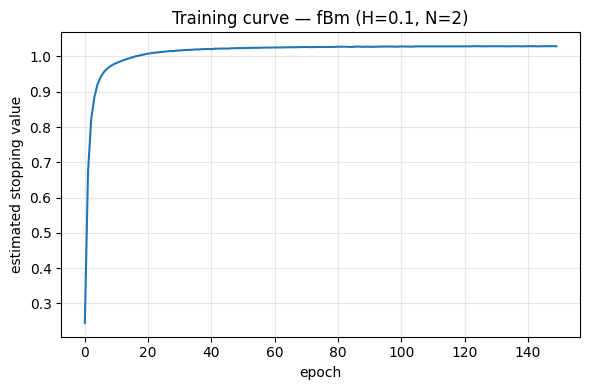

In [9]:
# Out-of-sample evaluation (low-biased estimate)
paths_ev = simulate_fbm(M_EVAL, J, H, T, seed=SEED + 99)
payoffs_ev = torch.from_numpy(paths_ev)
features_ev = prefix_logsignatures(time_augment(torch.from_numpy(paths_ev).unsqueeze(-1), T), DEPTH)

est, se = lower_bound(policy_fbm, features_ev, payoffs_ev)
print(f"fBm, H={H}, deep log-sig N={DEPTH}")
print(f"  lower-bound estimate : {est:.4f}  (±{2 * se:.4f}, 95% CI)")
print(f"  paper, Table 2       : 1.030")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([-x for x in history_fbm], lw=1.5)
ax.set_xlabel("epoch")
ax.set_ylabel("estimated stopping value")
ax.set_title(f"Training curve — fBm (H={H}, N={DEPTH})")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Experiment 2 — Linear signature policy

Same problem, now with the linear policy $\theta_l = \langle l, \hat X^{\le N}\rangle$ on the
**full** signature at depth $N = 3$ ($\sigma_{2,3} = 14$ coefficients). Reference value
(Table 2, $H=0.1$, linear $N{=}3$): **0.760**.

As reported in Section 8.1, the linear method underperforms the deep log-signature method at
every truncation level: the truncation error introduced by the shuffle-exponential
approximation dominates unless $N$ (and hence the cost) grows substantially.


In [10]:
DEPTH_LIN = 3
M_TRAIN_LIN = 16_384

paths_lin = simulate_fbm(M_TRAIN_LIN, J, H, T, seed=SEED + 1)
payoffs_lin = torch.from_numpy(paths_lin)
features_lin = prefix_signatures(time_augment(torch.from_numpy(paths_lin).unsqueeze(-1), T), DEPTH_LIN)
print(f"full signature dimension sigma_{{2,{DEPTH_LIN}}} = {features_lin.shape[-1]}")

policy_lin = LinearSignaturePolicy(features_lin.shape[-1])
history_lin = train(policy_lin, features_lin, payoffs_lin,
                    n_epochs=100, batch_size=512, lr=5e-4)

paths_lin_ev = simulate_fbm(M_EVAL, J, H, T, seed=SEED + 100)
features_lin_ev = prefix_signatures(time_augment(torch.from_numpy(paths_lin_ev).unsqueeze(-1), T), DEPTH_LIN)

est_lin, se_lin = lower_bound(policy_lin, features_lin_ev, torch.from_numpy(paths_lin_ev))
print(f"\nfBm, H={H}, linear signature policy N={DEPTH_LIN}")
print(f"  lower-bound estimate : {est_lin:.4f}  (±{2 * se_lin:.4f}, 95% CI)")
print(f"  paper, Table 2       : 0.760")


full signature dimension sigma_{2,3} = 14
epoch   1/100   estimated value 0.06417
epoch  10/100   estimated value 0.65155
epoch  20/100   estimated value 0.70741
epoch  30/100   estimated value 0.72277
epoch  40/100   estimated value 0.72961
epoch  50/100   estimated value 0.73348
epoch  60/100   estimated value 0.73597
epoch  70/100   estimated value 0.73751
epoch  80/100   estimated value 0.73843
epoch  90/100   estimated value 0.73887
epoch 100/100   estimated value 0.73905

fBm, H=0.1, linear signature policy N=3
  lower-bound estimate : 0.7378  (±0.0040, 95% CI)
  paper, Table 2       : 0.760


## 8. Experiment 3 — American put in a rough electricity market

Setup of Section 8.2: $S_t = e^{X_t}$ with $x_0 = 100$, $\alpha = -0.4$, $\lambda = 0.02$,
$\sigma = 0.2$; payoff $Y_t = e^{-rt}(K - S_t)^+$ with $r = 0.05$, $T = 1$, $J = 100$.

Deep log-signature policy at $N = 2$; reference value for $K = 100$ (Table 3): **18.279**
(European price: 5.770 — the early-exercise premium is large in this rough model).


In [11]:
ALPHA, LAM, SIGMA_EL = -0.4, 0.02, 0.2
S0, RATE, STRIKE = 100.0, 0.05, 100.0
DEPTH_EL = 2
M_TRAIN_EL = 65_536

log_prices = simulate_electricity_log_price(
    M_TRAIN_EL, J, T, x0=np.log(S0), alpha=ALPHA, lam=LAM, sigma=SIGMA_EL, seed=SEED)
prices = np.exp(log_prices)

t_grid = np.linspace(0.0, T, J + 1)
payoffs_el = torch.from_numpy(
    (np.exp(-RATE * t_grid) * np.maximum(STRIKE - prices, 0.0)).astype(np.float32))

features_el = prefix_logsignatures(
    time_augment(torch.from_numpy(prices).unsqueeze(-1), T), DEPTH_EL)

policy_el = DeepSignaturePolicy(features_el.shape[-1])
history_el = train(policy_el, features_el, payoffs_el,
                   n_epochs=100, batch_size=1_024, lr=1e-3)


epoch   1/100   estimated value 10.15392
epoch  10/100   estimated value 17.95547
epoch  20/100   estimated value 18.11097
epoch  30/100   estimated value 18.15831
epoch  40/100   estimated value 18.18269
epoch  50/100   estimated value 18.18937
epoch  60/100   estimated value 18.19735
epoch  70/100   estimated value 18.20038
epoch  80/100   estimated value 18.20568
epoch  90/100   estimated value 18.20933
epoch 100/100   estimated value 18.21112


In [12]:
log_prices_ev = simulate_electricity_log_price(
    M_EVAL, J, T, x0=np.log(S0), alpha=ALPHA, lam=LAM, sigma=SIGMA_EL, seed=SEED + 7)
prices_ev = np.exp(log_prices_ev)
payoffs_el_ev = torch.from_numpy(
    (np.exp(-RATE * t_grid) * np.maximum(STRIKE - prices_ev, 0.0)).astype(np.float32))
features_el_ev = prefix_logsignatures(
    time_augment(torch.from_numpy(prices_ev).unsqueeze(-1), T), DEPTH_EL)

est_el, se_el = lower_bound(policy_el, features_el_ev, payoffs_el_ev)
euro_price = payoffs_el_ev[:, -1].mean().item()

print(f"American put, K={STRIKE:.0f}, deep log-sig N={DEPTH_EL}")
print(f"  lower-bound estimate : {est_el:.3f}  (±{2 * se_el:.3f}, 95% CI)")
print(f"  paper, Table 3       : 18.279")
print(f"  European price (MC)  : {euro_price:.3f}   (paper: 5.770)")


American put, K=100, deep log-sig N=2
  lower-bound estimate : 18.214  (±0.050, 95% CI)
  paper, Table 3       : 18.279
  European price (MC)  : 5.749   (paper: 5.770)


## 9. Remarks

- The estimates are **low-biased** by construction (sub-optimal policy, evaluated
  out-of-sample); small gaps to the paper's values are expected since the paper trains on
  $2^{21}$ paths, while the sample sizes here are chosen to run comfortably on a laptop CPU.
- The dimension of the log-signature does **not** depend on the number of time steps $J$ —
  the same 3-dimensional feature ($d{=}2$, $N{=}2$) works for $J = 100$ or $J = 1000$. This is
  the key structural advantage over the Markovian lift of Becker–Cheridito–Jentzen (2019),
  which requires a $J$-dimensional state.
- Increasing $N$ improves the estimates but saturates quickly ($N \ge 3$ in both examples),
  consistent with Tables 2–3.

## References

- C. Bayer, P. Hager, S. Riedel, J. Schoenmakers (2021). *Optimal Stopping with Signatures.*
  [arXiv:2105.00778](https://arxiv.org/abs/2105.00778).
- S. Becker, P. Cheridito, A. Jentzen (2019). *Deep Optimal Stopping.* JMLR 20(74).
- M. Bennedsen (2017). *A rough multi-factor model of electricity spot prices.* Energy Economics 63.
- J. Kalsi, T. Lyons, I. Perez Arribas (2020). *Optimal execution with rough path signatures.* SIAM J. Fin. Math. 11(2).
- P. Kidger, T. Lyons (2021). *Signatory: differentiable computations of the signature and logsignature transforms, on both CPU and GPU.* ICLR.
